
## Laxmi Kanth Oruganti
### MSCS-634 : Advanced Big Data and Data Mining
### Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis Using Python in Jupyter Notebook


## Step 1: Data Collection  

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [98]:
# Upload dataset file
from google.colab import files
uploaded = files.upload()
uploaded

In [99]:
df = pd.read_csv('bmw_global_sales_2018_2025.csv')
df.sample(500)

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
1738,2022,7,China,X3,7699,58318,448990282,0.111,14.63,2.69,1.18
822,2020,2,USA,iX,5714,76455,436863870,0.085,18.43,3.08,1.13
1379,2021,8,Europe,X5,7386,67920,501657120,0.077,16.32,3.77,1.18
951,2020,6,USA,MINI,7187,43489,312555443,0.079,20.67,3.42,1.14
2746,2025,2,RestOfWorld,X3,2900,56171,162895900,0.197,6.05,3.94,1.39
...,...,...,...,...,...,...,...,...,...,...,...
2039,2023,4,USA,MINI,11227,40136,450606872,0.147,14.68,3.39,1.25
293,2018,10,Europe,i4,8061,64523,520119903,0.037,16.95,3.33,0.96
2269,2023,11,RestOfWorld,i4,8073,66018,532963314,0.130,5.65,2.12,1.29
787,2020,1,USA,X5,6351,70055,444919305,0.074,14.91,2.96,1.06


## Step 2: Data Visualization

Bar chart units sold in each year

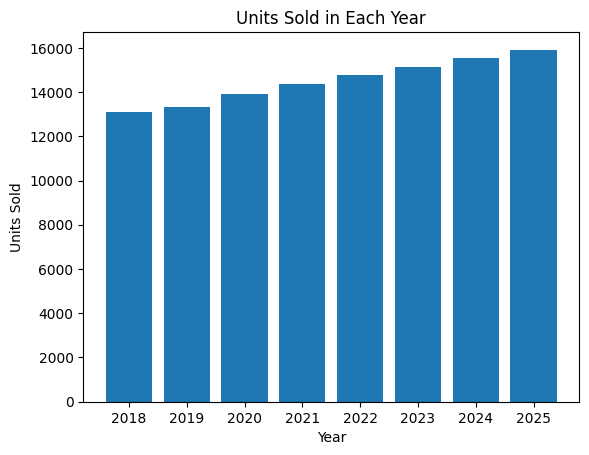

In [100]:
# bar chart units sold in each year
plt.bar(df['Year'], df['Units_Sold'])
plt.xlabel('Year')
plt.ylabel('Units Sold')
plt.title('Units Sold in Each Year')
plt.show()

Scatter plot GDP Growth vs. BEV Share (Battery Electric Vehicle penetration percentage) by Region with different colors

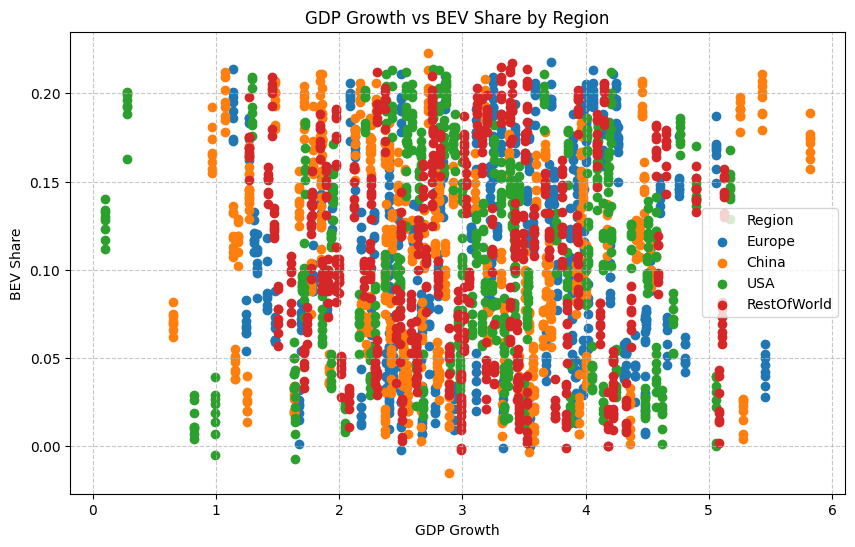

In [101]:
# scatter plot GDP Growth vs. BEV Share (Battery Electric Vehicle penetration percentage) by Region with different colors
plt.figure(figsize=(10, 6))
for region in df['Region'].unique():
    region_data = df[df['Region'] == region]
    plt.scatter(region_data['GDP_Growth'], region_data['BEV_Share'], label=region)
plt.xlabel('GDP Growth')
plt.ylabel('BEV Share')
plt.title('GDP Growth vs BEV Share by Region')
plt.legend(title='Region', loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Step 3: Data Preprocessing


1 - Handling Missing Values:

*   Detect and report missing values.
*   Apply techniques such as:
      * Filling with constants, forward fill, backward fill, or mean/mode replacement.
      * Dropping rows or columns based on conditions.

In [102]:
# Previous dataset (bmw_global_sales_2018_2025.csv) doesn't have missing values
# So, uploading Retail Product Dataset which has Missing Values
uploaded = files.upload()
uploaded

In [103]:
dfRetail = pd.read_csv('synthetic_dataset.csv')
dfRetail.sample(10)

,Category,Price,Rating,Stock,Discount
2191,A,4823.0,NaN,In Stock,35.0
3283,NaN,1383.0,NaN,Out of Stock,33.0
2160,NaN,9624.0,NaN,NaN,25.0
1525,A,2562.0,1.153528,In Stock,35.0
35,NaN,2331.0,3.952257,NaN,43.0
1904,B,8991.0,2.102078,Out of Stock,2.0
522,C,5369.0,NaN,NaN,29.0
812,NaN,3742.0,NaN,Out of Stock,3.0
2574,NaN,6373.0,4.607665,Out of Stock,26.0
621,NaN,166.0,4.983784,Out of Stock,45.0


Detect and report missing values.

In [104]:
# Detect and report missing values.
print(dfRetail.isnull().sum())
# print(dfRetail.isna().sum())


Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64


Filling with constants, forward fill, backward fill, or mean/mode replacement.

In [105]:
Price_mean_value = dfRetail['Price'].mean()

Rating_median_value = dfRetail['Rating'].median()

Discount_mode_value = dfRetail['Discount'].mode()[0]

print(Price_mean_value)
print(Rating_median_value)
print(Discount_mode_value)


5016.970630372492
3.0820600518841306
15.0


In [106]:
df_copy = dfRetail.copy()

df_copy['Price'] = df_copy['Price'].fillna(Price_mean_value)
df_copy['Rating'] = df_copy['Rating'].fillna(Rating_median_value)
df_copy['Discount'] = df_copy['Discount'].fillna(  Discount_mode_value)

print('Original Dataset')
print(dfRetail.head(25))
print('Modified Dataset')
print(df_copy.head(25))

Original Dataset
   Category   Price    Rating         Stock  Discount
0       NaN  5548.0  1.870322           NaN       0.0
1       NaN  3045.0  4.757798           NaN      38.0
2       NaN  4004.0       NaN      In Stock       0.0
3       NaN  4808.0  1.492085           NaN      33.0
4       NaN  1817.0       NaN  Out of Stock      23.0
5       NaN  3522.0       NaN           NaN       NaN
6         C   667.0  3.668341      In Stock      41.0
7         A  7125.0  4.983998  Out of Stock       7.0
8         A  2777.0  2.678384      In Stock       6.0
9       NaN   463.0  4.626187           NaN       3.0
10        A  1151.0  2.947838           NaN       NaN
11        A  3772.0  4.890750      In Stock      45.0
12      NaN  7719.0  2.982242      In Stock       4.0
13        C  8416.0  1.270943           NaN      29.0
14        B  8530.0       NaN           NaN      10.0
15        A  7936.0  3.032832      In Stock      44.0
16        B  9319.0  3.479064      In Stock      28.0
17      NaN

In [107]:
# forward fill, backward fill, and constant fill
df_copy2 = dfRetail.copy()
df_copy2['Rating'] = df_copy2['Rating'].fillna(method='ffill')
df_copy2['Discount'] = df_copy2['Discount'].fillna(method='bfill')
df_copy2['Category'] = df_copy2['Category'].fillna('Unknown')

print('Original Dataset')
print(dfRetail.head(25))
print('Modified Dataset')
print(df_copy2.head(25))


Original Dataset
   Category   Price    Rating         Stock  Discount
0       NaN  5548.0  1.870322           NaN       0.0
1       NaN  3045.0  4.757798           NaN      38.0
2       NaN  4004.0       NaN      In Stock       0.0
3       NaN  4808.0  1.492085           NaN      33.0
4       NaN  1817.0       NaN  Out of Stock      23.0
5       NaN  3522.0       NaN           NaN       NaN
6         C   667.0  3.668341      In Stock      41.0
7         A  7125.0  4.983998  Out of Stock       7.0
8         A  2777.0  2.678384      In Stock       6.0
9       NaN   463.0  4.626187           NaN       3.0
10        A  1151.0  2.947838           NaN       NaN
11        A  3772.0  4.890750      In Stock      45.0
12      NaN  7719.0  2.982242      In Stock       4.0
13        C  8416.0  1.270943           NaN      29.0
14        B  8530.0       NaN           NaN      10.0
15        A  7936.0  3.032832      In Stock      44.0
16        B  9319.0  3.479064      In Stock      28.0
17      NaN

/tmp/ipykernel_206/2580216927.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_copy2['Rating'] = df_copy2['Rating'].fillna(method='ffill')
/tmp/ipykernel_206/2580216927.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_copy2['Discount'] = df_copy2['Discount'].fillna(method='bfill')


Use IQR (Interquartile Range) or Standard Deviation techniques to identify and manage outliers.

In [108]:
# Use IQR (Interquartile Range) or Standard Deviation techniques to identify and manage outliers.
iqr_col = 'Discount'
std_dev_col = 'Rating'

q1 = dfRetail[iqr_col].quantile(0.25)
q3 = dfRetail[iqr_col].quantile(0.75)
iqr = q3 - q1

# calculate lower and upper bound
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr


outliers = ((dfRetail[iqr_col] < lower_bound) | (dfRetail[iqr_col] > upper_bound)).sum()
print("Outliers (IQR):")
print(outliers)

#  Standard Deviation techniques to identify and manage outliers.
mean = dfRetail[std_dev_col].mean()
std_dev = dfRetail[std_dev_col].std()

# calculate lower and upper bound
lower_bound = mean - 3 * std_dev
upper_bound = mean + 3 * std_dev

outliers = ((dfRetail[std_dev_col] < lower_bound) | (dfRetail[std_dev_col] > upper_bound)).sum()
print("Outliers (Standard deviation):")
print(outliers)


Outliers (IQR):
0
Outliers (Standard deviation):
0


3 -  Data Reduction:

*  Apply sampling (by number or percentage) to reduce data size.
*   Perform dimension elimination by dropping less relevant columns.

In [109]:
# Apply sampling (by number or percentage) to reduce data size.
print('----------- Original data -------------')
dfRetail.info()
# Sample 50 rows
df_sample_n = dfRetail.sample(n=50)
print('----------- Reduce data size by number -------------')
df_sample_n.info()

df_sample_pct = dfRetail.sample(frac=0.2)
print('----------- Reduce data size by percentage -------------')
df_sample_pct.info()


----------- Original data -------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4362 entries, 0 to 4361
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  1614 non-null   object 
 1   Price     4188 non-null   float64
 2   Rating    2312 non-null   float64
 3   Stock     3010 non-null   object 
 4   Discount  3970 non-null   float64
dtypes: float64(3), object(2)
memory usage: 170.5+ KB
----------- Reduce data size by number -------------
<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, 867 to 750
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  18 non-null     object 
 1   Price     49 non-null     float64
 2   Rating    30 non-null     float64
 3   Stock     41 non-null     object 
 4   Discount  45 non-null     float64
dtypes: float64(3), object(2)
memory usage: 2.3+ KB
----------- Reduce data size by percentage ------

In [110]:
# Perform dimension elimination by dropping less relevant columns
df_reduced = dfRetail.drop(['Category', 'Stock'], axis=1)
print('----------- Original data -------------')
dfRetail.info()
print('----------- Reduced data -------------')
df_reduced.info()


----------- Original data -------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4362 entries, 0 to 4361
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  1614 non-null   object 
 1   Price     4188 non-null   float64
 2   Rating    2312 non-null   float64
 3   Stock     3010 non-null   object 
 4   Discount  3970 non-null   float64
dtypes: float64(3), object(2)
memory usage: 170.5+ KB
----------- Reduced data -------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4362 entries, 0 to 4361
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     4188 non-null   float64
 1   Rating    2312 non-null   float64
 2   Discount  3970 non-null   float64
dtypes: float64(3)
memory usage: 102.4 KB


4. Data Scaling and Discretization:

*  Use techniques such as Min-Max Scaling, Z-score Standardization, or Decimal Scaling.  
*   Discretize continuous data into meaningful categories.

In [111]:
df_before_scaling = dfRetail.copy()
print("BEFORE scaling/discretization:")
dfRetail.describe().round(3)

BEFORE scaling/discretization:


,Price,Rating,Discount
count,4188.000,2312.000,3970.000
mean,5016.971,3.038,24.517
std,2839.985,1.143,14.347
min,102.000,1.000,0.000
25%,2628.250,2.069,12.000
50%,4996.500,3.082,25.000
75%,7418.000,4.009,37.000
max,9999.000,4.998,49.000


In [112]:
# Data Scaling using techniques such as Min-Max Scaling


# Min-Max scaling
p_min = df_before_scaling['Price'].min()
p_max = df_before_scaling['Price'].max()
df_before_scaling['Price_MinMax'] = ((df_before_scaling['Price'] - p_min) / (p_max - p_min)).round(6)
print("AFTER scaling/discretization:")
df_before_scaling.describe().round(3)
# df_before_scaling.head()

AFTER scaling/discretization:


,Price,Rating,Discount,Price_MinMax
count,4188.000,2312.000,3970.000,4188.000
mean,5016.971,3.038,24.517,0.497
std,2839.985,1.143,14.347,0.287
min,102.000,1.000,0.000,0.000
25%,2628.250,2.069,12.000,0.255
50%,4996.500,3.082,25.000,0.495
75%,7418.000,4.009,37.000,0.739
max,9999.000,4.998,49.000,1.000


In [113]:
# Z-score Standardization
df_before_scaling['Price_Zscore'] = (df_before_scaling['Price'] - df_before_scaling['Price'].mean()) / df_before_scaling['Price'].std()
print("AFTER scaling/discretization:")
df_before_scaling.describe().round(3)

AFTER scaling/discretization:


,Price,Rating,Discount,Price_MinMax,Price_Zscore
count,4188.000,2312.000,3970.000,4188.000,4188.000
mean,5016.971,3.038,24.517,0.497,0.000
std,2839.985,1.143,14.347,0.287,1.000
min,102.000,1.000,0.000,0.000,-1.731
25%,2628.250,2.069,12.000,0.255,-0.841
50%,4996.500,3.082,25.000,0.495,-0.007
75%,7418.000,4.009,37.000,0.739,0.845
max,9999.000,4.998,49.000,1.000,1.754


In [114]:
# Datascaling with Decimal Scaling v/10^j

j = len(str(int(df_before_scaling['Price'].max())))
print(f'j : {j}')
df_before_scaling['Price_Decimal'] = df_before_scaling['Price'] / (10**j)
print("AFTER scaling/discretization:")
df_before_scaling.sample(50)

j : 4
AFTER scaling/discretization:


,Category,Price,Rating,Stock,Discount,Price_MinMax,Price_Zscore,Price_Decimal
3509,D,3612.0,3.805960,NaN,NaN,0.354653,-0.494711,0.3612
2034,NaN,4775.0,1.970066,NaN,14.0,0.472163,-0.085201,0.4775
4005,NaN,669.0,3.801938,In Stock,16.0,0.057290,-1.530984,0.0669
4095,NaN,6159.0,2.965278,In Stock,36.0,0.612004,0.402125,0.6159
1584,NaN,4936.0,3.388591,NaN,32.0,0.488431,-0.028511,0.4936
772,NaN,7743.0,NaN,In Stock,45.0,0.772052,0.959875,0.7743
1832,NaN,3207.0,NaN,NaN,43.0,0.313731,-0.637317,0.3207
921,NaN,8406.0,1.291421,Out of Stock,11.0,0.839042,1.193327,0.8406
1696,B,9362.0,1.307787,In Stock,13.0,0.935637,1.529948,0.9362
3156,NaN,NaN,NaN,Out of Stock,35.0,NaN,NaN,NaN


In [115]:
display(df_before_scaling.head())

,Category,Price,Rating,Stock,Discount,Price_MinMax,Price_Zscore,Price_Decimal
0,NaN,5548.0,1.870322,NaN,0.0,0.550268,0.186983,0.5548
1,NaN,3045.0,4.757798,NaN,38.0,0.297363,-0.694360,0.3045
2,NaN,4004.0,NaN,In Stock,0.0,0.394261,-0.356682,0.4004
3,NaN,4808.0,1.492085,NaN,33.0,0.475498,-0.073582,0.4808
4,NaN,1817.0,NaN,Out of Stock,23.0,0.173285,-1.126756,0.1817


Discretize continuous data into meaningful categories.

In [116]:
# Binning based on price
dfRetail['Price_Category'] = pd.cut(dfRetail['Price'], bins=3, labels=['Budget', 'Mid-range', 'Premium'])

# Based on Rating
dfRetail['Rating_Label'] = pd.cut(dfRetail['Rating'], bins=[0, 2, 3.5, 4.5, 5], labels=['Poor', 'Average', 'Good', 'Excellent'])

print("AFTER discretization:")
dfRetail.head(100)



AFTER discretization:


,Category,Price,Rating,Stock,Discount,Price_Category,Rating_Label
0,NaN,5548.0,1.870322,NaN,0.0,Mid-range,Poor
1,NaN,3045.0,4.757798,NaN,38.0,Budget,Excellent
2,NaN,4004.0,NaN,In Stock,0.0,Mid-range,NaN
3,NaN,4808.0,1.492085,NaN,33.0,Mid-range,Poor
4,NaN,1817.0,NaN,Out of Stock,23.0,Budget,NaN
...,...,...,...,...,...,...,...
95,NaN,6578.0,3.125261,NaN,28.0,Mid-range,Average
96,NaN,7187.0,NaN,In Stock,12.0,Premium,NaN
97,NaN,1435.0,NaN,NaN,23.0,Budget,NaN
98,NaN,1561.0,2.856089,In Stock,6.0,Budget,Average


## Step 4: Statistical Analysis

General Overview of Data: Use .info() and .describe() to explore dataset characteristics.

In [117]:
# Use .info() and .describe() to explore dataset characteristics.
dfRetail.info()

dfRetail.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4362 entries, 0 to 4361
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Category        1614 non-null   object  
 1   Price           4188 non-null   float64 
 2   Rating          2312 non-null   float64 
 3   Stock           3010 non-null   object  
 4   Discount        3970 non-null   float64 
 5   Price_Category  4188 non-null   category
 6   Rating_Label    2312 non-null   category
dtypes: category(2), float64(3), object(2)
memory usage: 179.4+ KB


,Price,Rating,Discount
count,4188.000000,2312.000000,3970.000000
mean,5016.970630,3.038293,24.516625
std,2839.984813,1.143074,14.347164
min,102.000000,1.000366,0.000000
25%,2628.250000,2.069490,12.000000
50%,4996.500000,3.082060,25.000000
75%,7418.000000,4.008620,37.000000
max,9999.000000,4.997818,49.000000


Calculate Minimum, Maximum, Mean, Median, and Mode.

In [118]:
# Calculate Minimum, Maximum, Mean, Median, and Mode.
min = dfRetail['Price'].min()
max = dfRetail['Price'].max()
mean = dfRetail['Price'].mean().round(3)
median = dfRetail['Price'].median()
mode = dfRetail['Price'].mode()[0]

print(f'Min : {min}')
print(f'Max : {max}')
print(f'Mean : {mean}')
print(f'Median : {median}')
print(f'Mode : {mode}')

Min : 102.0
Max : 9999.0
Mean : 5016.971
Median : 4996.5
Mode : 1151.0


Compute Range, Quartiles, Interquartile Range (IQR), Variance, and Standard Deviation.

In [119]:
# Compute Range, Quartiles, Interquartile Range (IQR), Variance, and Standard Deviation.
range = max - min
print(f'Range : {range}')

q1 = dfRetail['Price'].quantile(0.25)
q3 = dfRetail['Price'].quantile(0.75)
iqr = q3 - q1
print(f'Q1 : {q1}')
print(f'Q3 : {q3}')
print(f'IQR : {iqr}')

variance = dfRetail['Price'].var()
print(f'Variance : {variance}')

std_dev = dfRetail['Price'].std()
print(f'Standard Deviation : {std_dev}')



Range : 9897.0
Q1 : 2628.25
Q3 : 7418.0
IQR : 4789.75
Variance : 8065513.740479472
Standard Deviation : 2839.9848134240915


Compute the correlation matrix for numerical columns using .corr().

In [120]:
correlation_matrix = dfRetail.corr(numeric_only=True)
print(correlation_matrix)

             Price    Rating  Discount
Price     1.000000  0.021099  0.009300
Rating    0.021099  1.000000  0.015028
Discount  0.009300  0.015028  1.000000
